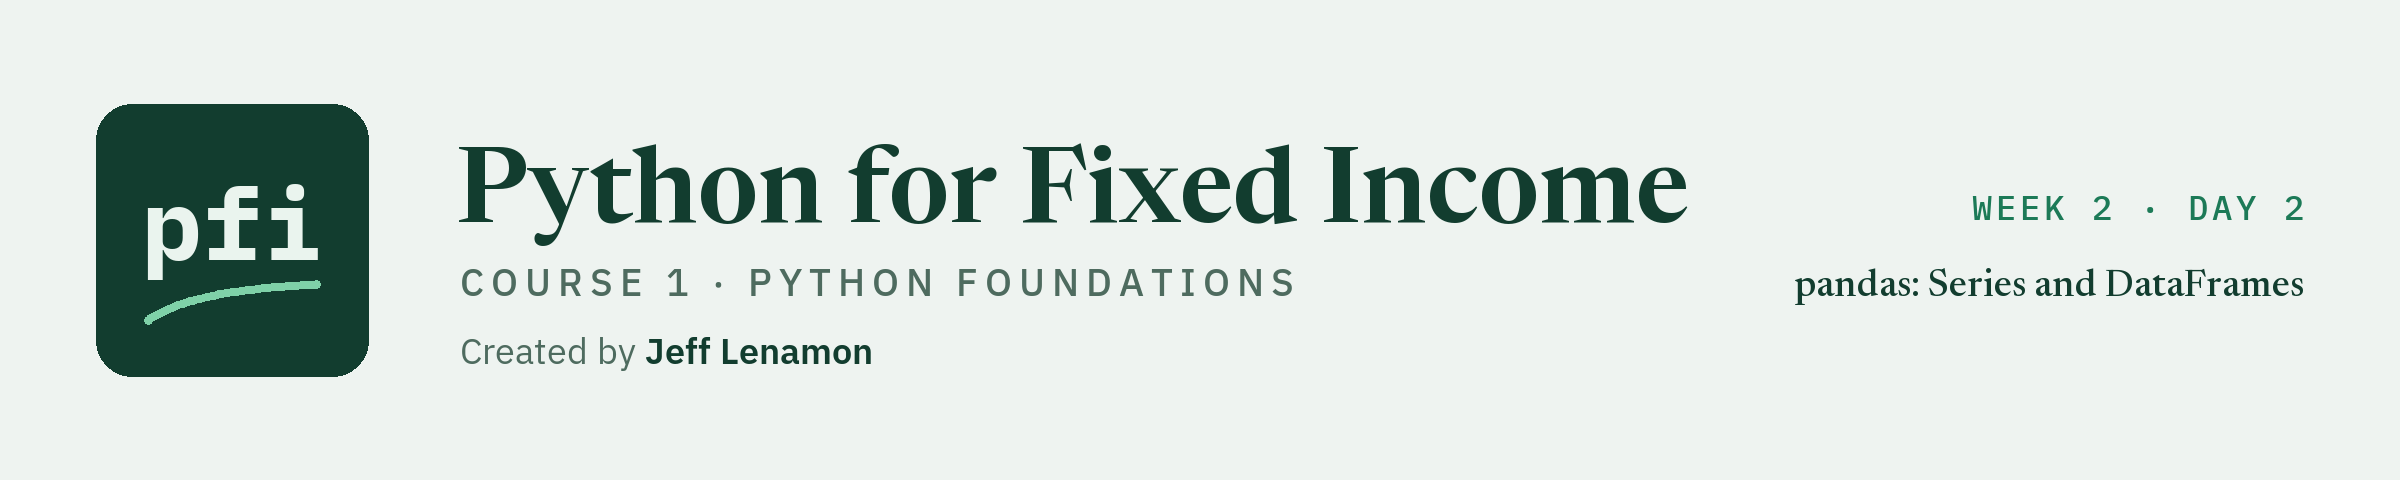

# pandas: Series and DataFrames

Week 2. Holding a whole portfolio in one table, and pulling out the rows and columns a question needs.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day2/07_pandas_series_and_dataframes.ipynb)

The credit desk's portfolio has grown from four bonds to two hundred. Each bond now comes with a CUSIP, an issuer name, a sector, a rating, a maturity date, a price, a spread, a duration, and a position size.

The tools so far do not fit that. A list or a dictionary holds the data but answers no questions without a loop. A NumPy array calculates on a whole column at once, but it holds one type of value and knows nothing about tickers or column names. The desk needs a table: text and numbers side by side, every column with a name, every row a bond.

**pandas** is the Python library for that. It has two structures. A **Series** is one labelled column. A **DataFrame** is a table of them. We build both by hand from the four bonds of week 1, then load the full holdings file and work on that for the rest of the lesson. The issuers are invented.

| Ticker | Coupon (%) | Maturity | Price | Face held | Rating |
| --- | --- | --- | --- | --- | --- |
| QVNE | 5.25 | 2033 | 98.50 | 1,500,000 | BBB |
| DNMR | 6.125 | 2034 | 103.25 | 500,000 | BB+ |
| PLWK | 4.75 | 2031 | 95.00 | 750,000 | A- |
| HLVF | 7.50 | 2032 | 101.00 | 250,000 | B+ |

## 7.1 A Series: One Labelled Column

We met pandas briefly at the end of week 1. It was installed when you set up the environment from `requirements.txt`, and in Google Colab it is already installed.

Q. Import pandas.

In [1]:
# import the library and give it the short name pd
import pandas as pd

* `pd` is the name everyone uses for pandas, the same way `np` is the name for NumPy.

Q. Put the four prices in a Series.

In [2]:
# the prices as a list, as in week 1
price_list = [98.5, 103.25, 95.0, 101.0]

# pd.Series() turns a list into a Series
prices = pd.Series(price_list)
print(prices)

0     98.50
1    103.25
2     95.00
3    101.00
dtype: float64


* The four prices are in the right-hand column. The left-hand column, 0 to 3, is the **index**: a label for each row. We gave no labels, so pandas numbered the rows.
* The last line, `dtype: float64`, is the type of the values, as in NumPy.

A row number says nothing about which bond a price belongs to. The index can hold something more useful.

Q. Label each price with its ticker.

In [3]:
ticker_list = ['QVNE', 'DNMR', 'PLWK', 'HLVF']

# index= sets the label of each row
prices = pd.Series(price_list, index=ticker_list)
print(prices)

QVNE     98.50
DNMR    103.25
PLWK     95.00
HLVF    101.00
dtype: float64


* Each price now sits next to its ticker. In NumPy the tickers and the prices were two separate arrays that we had to keep in the same order ourselves. In a Series the label travels with the value.

Q. What is inside a Series?

In [4]:
# values holds the data
print(prices.values)
print(type(prices.values))
# index holds the labels
print(prices.index)

[ 98.5  103.25  95.   101.  ]
<class 'numpy.ndarray'>
Index(['QVNE', 'DNMR', 'PLWK', 'HLVF'], dtype='str')


* The values are a NumPy array: square brackets, no commas, type `numpy.ndarray`. A Series is a NumPy array with an index attached, so everything from the NumPy notebook about arithmetic on a whole column still applies.
* The index holds the four tickers. Its `dtype` is the type of the labels. Text shows as `str` in pandas 3 and as `object` in older versions. That is the only difference, and you will see the same note wherever a text column appears below.

Q. What is the price of PLWK? And what is the first price in the Series?

In [5]:
# square brackets with a label look up the value for that label
print('PLWK:', prices['PLWK'])
# iloc looks up by position, counting from 0
print('First price:', prices.iloc[0])

PLWK: 95.0
First price: 98.5


* 95.0 for PLWK and 98.5 for the first row, which is QVNE.
* A label in square brackets works like a key in a dictionary. `iloc` stands for 'integer location' and works like an index in a list. Section 7.5 covers both properly.

Q. How much coupon does each position pay in a year? The coupon is in percent of face.

In [6]:
# two more Series with the same labels
coupons = pd.Series([5.25, 6.125, 4.75, 7.5], index=ticker_list)
faces = pd.Series([1500000, 500000, 750000, 250000], index=ticker_list)

# arithmetic applies to every row, as with arrays
incomes = faces * coupons / 100
print(incomes)

# the array methods from the NumPy notebook work on a Series
print('Total annual coupon income:', incomes.sum())

QVNE    78750.0
DNMR    30625.0
PLWK    35625.0
HLVF    18750.0
dtype: float64
Total annual coupon income: 163750.0


* 78,750 for QVNE, then 30,625, 35,625, and 18,750: the same figures as in the NumPy notebook, now with a ticker beside each one.
* The total is 163,750, which matches week 1. `sum()`, `mean()`, `min()`, and `max()` work on a Series as they do on an array.

There is one thing a Series does that an array cannot. Suppose the face amounts arrive from another system in a different order.

Q. Work out the coupon income again, with the face amounts listed from the smallest position to the largest.

In [7]:
# the same four face amounts, in a different order
faces_by_size = pd.Series([250000, 500000, 750000, 1500000],
                          index=['HLVF', 'DNMR', 'PLWK', 'QVNE'])

# pandas matches the rows by label, not by position
print(faces_by_size * coupons / 100)

DNMR    30625.0
HLVF    18750.0
PLWK    35625.0
QVNE    78750.0
dtype: float64


* The four incomes are the same as before: 78,750 for QVNE, 30,625 for DNMR, 35,625 for PLWK, and 18,750 for HLVF. The rows print in alphabetical order because pandas sorts the labels when the two indexes are not in the same order.
* pandas lined the two Series up by ticker before multiplying. Two NumPy arrays in different orders would have been multiplied position by position, with no error and four wrong numbers.

**Excel side by side.** A Series is a single column of a worksheet with a label on every row, close to a named range with the tickers in the column beside it. Multiplying two Series is a formula filled down. The matching by label is what a `VLOOKUP` on the ticker does before the multiplication, and pandas does it without being asked.

## 7.2 A DataFrame: A Table of Columns

A DataFrame is a set of Series that share one index: a table. At the end of week 1 we built one from a dictionary of lists.

Q. Put the four bonds in a DataFrame.

In [8]:
# each key is a column name and each list is a column
desk = pd.DataFrame({
    'Ticker': ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    'Coupon': [5.25, 6.125, 4.75, 7.5],
    'Maturity': [2033, 2034, 2031, 2032],
    'Price': [98.5, 103.25, 95.0, 101.0],
    'Face': [1500000, 500000, 750000, 250000],
    'Rating': ['BBB', 'BB+', 'A-', 'B+'],
})

# a variable name on the last line of a cell displays the table
desk

,Ticker,Coupon,Maturity,Price,Face,Rating
0,QVNE,5.250,2033,98.50,1500000,BBB
1,DNMR,6.125,2034,103.25,500000,BB+
2,PLWK,4.750,2031,95.00,750000,A-
3,HLVF,7.500,2032,101.00,250000,B+


* Four rows and six columns, with text and numbers side by side. That is what an array could not hold.
* The numbers 0 to 3 down the left are the index. As with the first Series, pandas numbered the rows because we gave no labels.

Q. What are the column names and the row labels of the table?

In [9]:
# columns holds the column names
print(desk.columns)
# index holds the row labels
print(desk.index)

Index(['Ticker', 'Coupon', 'Maturity', 'Price', 'Face', 'Rating'], dtype='str')
RangeIndex(start=0, stop=4, step=1)


* The six column names, in the order of the dictionary. Older versions of pandas show `dtype='object'` where this shows `dtype='str'`.
* `RangeIndex(start=0, stop=4, step=1)` is the default numbering: 0, 1, 2, 3. Like `range()`, it stops before 4.

Q. What type of value does each column hold, and how many rows and columns does the table have?

In [10]:
# dtypes lists the type of every column
print(desk.dtypes)
# shape is (rows, columns)
print(desk.shape)

Ticker          str
Coupon      float64
Maturity      int64
Price       float64
Face          int64
Rating          str
dtype: object
(4, 6)


* Coupon and Price are `float64`, numbers with a decimal point. Maturity and Face are `int64`, whole numbers. Ticker and Rating are text: `str` here, `object` in older versions of pandas.
* Each column has one type, like an array. The table as a whole can mix them.
* The shape is (4, 6): four bonds, six attributes. Rows come first, as in a 2-D array.

Q. Pull the Price column out of the table. What type is it?

In [11]:
# square brackets with a column name select that column
desk_prices = desk['Price']
print(desk_prices)
print(type(desk_prices))

0     98.50
1    103.25
2     95.00
3    101.00
Name: Price, dtype: float64
<class 'pandas.Series'>


* The four prices, with the row index on the left and the column name on the last line. The type is `Series`.
* This is the link between the two structures. Every column of a DataFrame is a Series, so everything in section 7.1 works on a column of a table.

**Excel side by side.** A DataFrame is a worksheet with a header row. The column names are the headers, the index is the row numbers down the left edge, and `desk['Price']` is the Price column selected by its header.

## 7.3 The Holdings File

Nobody types two hundred bonds into a dictionary. The desk's holdings arrive as a CSV file, `holdings.csv`, in the `data` folder of the course repo.

Q. Load the holdings file into a DataFrame.

In [12]:
import os

# on your own machine the file is in the repo's data folder. In Colab it is read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    data_path = '../../../data/holdings.csv'
else:
    data_path = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/holdings.csv'

holdings = pd.read_csv(data_path)

* `pd.read_csv()` reads a CSV file and returns a DataFrame. The first line of the file becomes the column names.
* The `if` picks where to read from. On your own machine the file is two folders up from this notebook, in `data`. In Colab that folder does not exist, so pandas reads the same file from the course's GitHub page. Reading and saving files is covered properly in the next notebook.

Q. What do the first rows look like?

In [13]:
# head() shows the first 5 rows
holdings.head()

,as_of_date,cusip,ticker,issuer,sector,rating,coupon,maturity,price,price_date,accrued,yield_pct,oas,duration,spread_duration,dts,amount_outstanding,par_held,market_value
0,2026-09-30,99080CAE8,BEZE,Bezane Finance,Financials,BBB-,7.000,2032-06-18,106.727,2026-09-30,1.983,5.606,147,4.627,4.627,680.2,1650000000,5000000,5435500.0
1,2026-09-30,99049XAE2,BEZH,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.556,2026-09-30,3.679,9.220,535,2.165,2.165,1158.3,950000000,250000,253087.5
2,2026-09-30,99039NAC0,BEZL,Bezoquil Freight,Transportation,BB,5.125,2030-06-03,98.730,2026-09-30,1.666,5.509,153,3.250,3.250,497.2,850000000,1500000,1505940.0
3,2026-09-30,99039NAG1,BEZL,Bezoquil Freight,Transportation,BB,6.125,2053-04-09,92.261,2026-09-30,2.909,6.756,218,12.113,12.113,2640.6,2200000000,500000,475850.0
4,2026-09-30,99034IAD4,BEZN,Bezorin Finance,Financials,BBB-,4.625,2036-04-05,92.883,2026-09-30,2.248,5.600,127,7.338,7.338,931.9,1100000000,2500000,2378275.0


* One row per bond. The table is wide, so scroll to the right to see every column.
* The third and fourth rows share an issuer: BEZL has two bonds with different coupons and maturities. Each bond has its own CUSIP.

Q. And the last rows?

In [14]:
# tail(3) shows the last 3 rows
holdings.tail(3)

,as_of_date,cusip,ticker,issuer,sector,rating,coupon,maturity,price,price_date,accrued,yield_pct,oas,duration,spread_duration,dts,amount_outstanding,par_held,market_value
197,2026-09-30,99062KAA0,ZEPL,Zephizal Medical,Health Care,A-,4.125,2036-11-12,90.863,2026-09-30,1.581,5.303,95,7.919,7.919,752.3,1450000000,1250000,1155550.0
198,2026-09-30,99138IAD9,ZEPN,Zephiskan Resources,Energy,A-,7.250,2031-09-13,110.669,2026-09-30,0.342,4.803,72,4.177,4.177,300.7,2250000000,750000,832582.5
199,2026-09-30,99138IAF4,ZEPN,Zephiskan Resources,Energy,A-,5.000,2036-08-16,93.656,2026-09-30,0.611,5.854,151,7.565,7.565,1142.3,350000000,2500000,2356675.0


* The index of the last row is 199. Counting starts at 0, so that makes 200 rows.

Q. How large is the table?

In [15]:
print(holdings.shape)

(200, 19)


* (200, 19): 200 bonds, 19 columns.

Q. What are the columns?

In [16]:
holdings.columns

Index(['as_of_date', 'cusip', 'ticker', 'issuer', 'sector', 'rating', 'coupon',
       'maturity', 'price', 'price_date', 'accrued', 'yield_pct', 'oas',
       'duration', 'spread_duration', 'dts', 'amount_outstanding', 'par_held',
       'market_value'],
      dtype='str')

* Nineteen names, all lower case with underscores in place of spaces. Older versions of pandas show `dtype='object'` on the last line.

Here is what each column holds. Every bond is a fixed-rate bullet bond that pays semiannual coupons on a 30/360 day count.

| Column | Meaning | Units |
| --- | --- | --- |
| `as_of_date` | Date of the holdings report | date as text |
| `cusip` | Identifier of the bond, invented | text |
| `ticker` | Short code of the issuer | text |
| `issuer` | Name of the issuer, invented | text |
| `sector` | Sector of the issuer | text |
| `rating` | Credit rating of the bond | text |
| `coupon` | Annual coupon | percent of face |
| `maturity` | Maturity date | date as text |
| `price` | Clean price | per 100 of face |
| `price_date` | Date of the price | date as text |
| `accrued` | Accrued interest | per 100 of face |
| `yield_pct` | Yield to maturity | percent |
| `oas` | Option-adjusted spread | basis points |
| `duration` | Modified duration | years |
| `spread_duration` | Spread duration | years |
| `dts` | Duration times spread: `spread_duration` times `oas` | years times basis points |
| `amount_outstanding` | Size of the whole bond issue | dollars of face |
| `par_held` | Face amount the desk holds | dollars of face |
| `market_value` | `par_held` times (`price` plus `accrued`), divided by 100 | dollars |

Q. What type is each column, and is anything missing?

In [17]:
# info() lists each column with its count of values and its type
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   as_of_date          200 non-null    str    
 1   cusip               200 non-null    str    
 2   ticker              200 non-null    str    
 3   issuer              200 non-null    str    
 4   sector              200 non-null    str    
 5   rating              200 non-null    str    
 6   coupon              200 non-null    float64
 7   maturity            200 non-null    str    
 8   price               200 non-null    float64
 9   price_date          200 non-null    str    
 10  accrued             200 non-null    float64
 11  yield_pct           200 non-null    float64
 12  oas                 200 non-null    int64  
 13  duration            200 non-null    float64
 14  spread_duration     200 non-null    float64
 15  dts                 200 non-null    float64
 16  amount_outstanding 

* Every column has 200 non-null values, so nothing is missing.
* Eight columns are text, eight are `float64`, and three are `int64`. Text columns show as `str` in pandas 3 and as `object` in older versions.
* The three date columns are text for now. Turning them into real dates is a topic for the next notebook.

## 7.4 Selecting Columns

Most questions need two or three of the nineteen columns. Selecting them is the first skill.

Q. Show the spread of the first five bonds.

In [18]:
# one column name in square brackets returns that column as a Series
holdings['oas'].head()

0    147
1    535
2    153
3    218
4    127
Name: oas, dtype: int64

* 147, 535, 153, 218, and 127 basis points. `head()` works on a Series as it does on a table.

Column names must match exactly. What happens if we type the name the way it is usually written on a desk?

In [19]:
# the column is named oas, in lower case
holdings['OAS']

KeyError: 'OAS'

* A `KeyError: 'OAS'`. The traceback is long because the error passes through several layers of pandas. Go straight to the last line: it names the key that could not be found.
* This is the same error a dictionary gives for a missing key. Column names are case-sensitive, so `'OAS'` and `'oas'` are different names. When you see a `KeyError`, compare your spelling with `holdings.columns`.

Q. Show the ticker, coupon, maturity, and price of the first five bonds.

In [20]:
# a list of column names inside the square brackets returns a smaller table
holdings[['ticker', 'coupon', 'maturity', 'price']].head()

,ticker,coupon,maturity,price
0,BEZE,7.000,2032-06-18,106.727
1,BEZH,8.125,2029-04-17,97.556
2,BEZL,5.125,2030-06-03,98.730
3,BEZL,6.125,2053-04-09,92.261
4,BEZN,4.625,2036-04-05,92.883


* Four columns, in the order we asked for them.
* Note the double square brackets. The outer pair is the selection and the inner pair is a list of names. One name gives a Series. A list of names gives a DataFrame, even when the list has one name in it.

Q. Summarize the coupon, price, yield, spread, and duration columns.

In [21]:
# describe() gives the count, mean, standard deviation, minimum, quartiles, and maximum
holdings[['coupon', 'price', 'yield_pct', 'oas', 'duration']].describe()

,coupon,price,yield_pct,oas,duration
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,5.937500,98.828295,6.087815,185.750000,6.470405
std,1.648435,7.404931,1.957543,193.949632,3.350506
min,3.250000,62.045000,4.089000,19.000000,0.927000
25%,4.750000,95.140000,5.058750,81.750000,3.880250
50%,5.687500,99.416000,5.547000,135.500000,6.306500
75%,6.875000,103.004000,6.394500,213.000000,8.139750
max,11.000000,119.131000,19.304000,1551.000000,16.042000


**Observations**

* Coupons run from 3.25 to 11 percent, with a mean of 5.9375.
* Prices run from 62.045 to 119.131. The median, in the 50% row, is 99.416, so about half of the bonds are priced below par.
* The spread column is lopsided. The median OAS is 135.5 basis points and the mean is 185.75, with a maximum of 1,551. A few very wide bonds pull the mean above the median.
* Durations run from 0.927 to 16.042 years, with a mean of about 6.47.

**Excel side by side.** Selecting columns is hiding the columns you do not need, or copying a few of them to a new sheet. `describe()` has no single Excel function. It is `COUNT`, `AVERAGE`, `STDEV.S`, `MIN`, `QUARTILE.INC`, and `MAX` on every column at once.

## 7.5 Rows by Position and by Label

A column is selected by name. A row can be selected two ways: by its position in the table, with `iloc`, or by its label in the index, with `loc`.

Q. Show the first bond in the table.

In [22]:
# iloc[0] is the row at position 0
holdings.iloc[0]

as_of_date                2026-09-30
cusip                      99080CAE8
ticker                          BEZE
issuer                Bezane Finance
sector                    Financials
rating                          BBB-
coupon                           7.0
maturity                  2032-06-18
price                        106.727
price_date                2026-09-30
accrued                        1.983
yield_pct                      5.606
oas                              147
duration                       4.627
spread_duration                4.627
dts                            680.2
amount_outstanding        1650000000
par_held                     5000000
market_value               5435500.0
Name: 0, dtype: object

* One row comes back as a Series, turned on its side: the column names are now the labels. The first bond is BEZE, a 7% bond of 2032 rated BBB-.
* The last line says `dtype: object`. A row mixes text and numbers, and `object` is the type pandas uses for a mix.

Q. Show the first three bonds, and only the first four columns.

In [23]:
# iloc[rows, columns], both by position. A slice stops before its end.
holdings.iloc[0:3, 0:4]

,as_of_date,cusip,ticker,issuer
0,2026-09-30,99080CAE8,BEZE,Bezane Finance
1,2026-09-30,99049XAE2,BEZH,Bezamyth Machinery
2,2026-09-30,99039NAC0,BEZL,Bezoquil Freight


* Rows 0, 1, and 2, and columns 0 to 3. As with lists and arrays, the end of the slice is left out.
* `iloc` takes positions only. It is the way to say 'the first three rows' or 'the last row' (`iloc[-1]`), whatever the table holds.

Positions are fragile. Sort the table or remove a bond, and position 0 is a different bond. A label stays with its row. The best label for a bond is its CUSIP, because no two bonds share one.

Q. Make the CUSIP the index of the table.

In [24]:
# set_index() returns a new table with that column as the row labels
by_cusip = holdings.set_index('cusip')
by_cusip[['ticker', 'coupon', 'maturity', 'price']].head(3)

,ticker,coupon,maturity,price
cusip,,,,
99080CAE8,BEZE,7.000,2032-06-18,106.727
99049XAE2,BEZH,8.125,2029-04-17,97.556
99039NAC0,BEZL,5.125,2030-06-03,98.730


* The CUSIPs have moved to the left edge, in bold, in place of the numbers 0, 1, 2.
* `set_index()` did not change `holdings`. It returned a new table, which we stored as `by_cusip`. Most pandas methods work this way: they hand back a new table and leave the original alone.
* The ticker would be a poor index here, because one issuer can have several bonds. We count them in section 7.6.

Q. Show the bond with CUSIP 99039NAC0.

In [25]:
# loc looks a row up by its label
by_cusip.loc['99039NAC0']

as_of_date                  2026-09-30
ticker                            BEZL
issuer                Bezoquil Freight
sector                  Transportation
rating                              BB
coupon                           5.125
maturity                    2030-06-03
price                            98.73
price_date                  2026-09-30
accrued                          1.666
yield_pct                        5.509
oas                                153
duration                          3.25
spread_duration                   3.25
dts                              497.2
amount_outstanding           850000000
par_held                       1500000
market_value                 1505940.0
Name: 99039NAC0, dtype: object

* BEZL 5.125% of 2030, rated BB, priced at 98.73 with an OAS of 153.
* We did not need to know where in the table the bond sits.

Q. What is the price of that bond?

In [26]:
# loc[row label, column name] returns a single value
print(by_cusip.loc['99039NAC0', 'price'])

98.73


* 98.73. The row label comes first and the column name second. Either one can also be a list, to get several rows or several columns at once.

Slices work with labels too, with one difference from everything so far.

Q. Show the first three bonds twice: once by position, and once by label, from 99080CAE8 to 99039NAC0.

In [27]:
# by position: stops before position 3
print(by_cusip.iloc[0:3]['ticker'])
print()
# by label: includes the end label
print(by_cusip.loc['99080CAE8':'99039NAC0']['ticker'])

cusip
99080CAE8    BEZE
99049XAE2    BEZH
99039NAC0    BEZL
Name: ticker, dtype: str

cusip
99080CAE8    BEZE
99049XAE2    BEZH
99039NAC0    BEZL
Name: ticker, dtype: str


* The same three bonds both times: BEZE, BEZH, and BEZL.
* An `iloc` slice leaves out its end, like every slice in Python. A `loc` slice includes its end. With labels there is no 'one past the end' to name, so pandas takes both ends.
* The last line of each output shows the type of the ticker column: `str` here, `object` in older versions of pandas.

What happens when the label is not in the index? Here the last character of the CUSIP is mistyped.

In [28]:
# the real CUSIP ends in 8
by_cusip.loc['99080CAE9']

KeyError: '99080CAE9'

* A `KeyError: '99080CAE9'`. Again the last line of the traceback names the label that was not found.
* pandas does not guess the nearest match. One wrong character and the lookup fails, which is what we want from a lookup of a security.

**Excel side by side.**

| Question | pandas | Excel |
| --- | --- | --- |
| The third row | `holdings.iloc[2]` | row 4 of the sheet, under the header |
| Price of a CUSIP | `by_cusip.loc['99039NAC0', 'price']` | `=VLOOKUP("99039NAC0", B:I, 8, FALSE)` |
| The same, without counting columns | `by_cusip.loc['99039NAC0', 'price']` | `=INDEX(I:I, MATCH("99039NAC0", B:B, 0))` |
| A CUSIP that is not there | `KeyError` | `#N/A` |

The Excel formulas assume the CUSIP in column B and the price in column I, as in `holdings.csv`. `loc` is `INDEX` and `MATCH` in one step, and it uses the column's name where `VLOOKUP` needs its number.

## 7.6 Column Statistics

A column is a Series, so the summary methods from section 7.1 work on any column of the holdings.

Q. What is the total market value of the portfolio, and how much face does the desk hold?

In [29]:
# sum() adds up the column
print('Total market value:', holdings['market_value'].sum())
print('Total face held:', holdings['par_held'].sum())

Total market value: 490819215.0
Total face held: 489000000


* 490,819,215 of market value on 489,000,000 of face.

Q. What are the average and the median spread, and the lowest and highest price?

In [30]:
print('Mean OAS:', holdings['oas'].mean())
print('Median OAS:', holdings['oas'].median())
print('Lowest price:', holdings['price'].min())
print('Highest price:', holdings['price'].max())

Mean OAS: 185.75
Median OAS: 135.5
Lowest price: 62.045
Highest price: 119.131


* A mean of 185.75 basis points and a median of 135.5. The lowest price is 62.045 and the highest 119.131. These are the figures `describe()` showed in section 7.4, one at a time.
* `median()` is the middle value: half of the bonds are above it and half below.

Q. How many bonds does the desk hold in each sector?

In [31]:
# value_counts() counts how many times each value appears, largest first
holdings['sector'].value_counts()

sector
Financials        26
Consumer          26
Materials         26
Telecom           21
Industrials       20
Transportation    20
Health Care       20
Energy            17
Utilities         12
Technology        12
Name: count, dtype: int64

* Ten sectors. Financials, Consumer, and Materials have 26 bonds each. Utilities and Technology have the fewest, with 12 each.
* The last line shows `int64`, the type of the counts.

Q. How many bonds are there at each rating?

In [32]:
holdings['rating'].value_counts()

rating
A-      28
BBB-    26
BB+     23
BBB+    21
BB      16
A+      16
BBB     15
A       12
BB-     10
B-       7
B+       6
B        5
AA-      4
CCC+     4
AA       3
AAA      2
AA+      1
CCC      1
Name: count, dtype: int64

* Eighteen ratings, from AAA down to CCC. The most common is A- with 28 bonds, then BBB- with 26 and BB+ with 23. There are 2 bonds rated AAA and 1 rated CCC.
* The rows are in order of count, not in order of credit quality.

Q. List the sectors. And does the report date differ from row to row?

In [33]:
# unique() returns each distinct value once. tolist() turns the result into a plain list.
print(holdings['sector'].unique().tolist())
print(holdings['as_of_date'].unique().tolist())

['Financials', 'Industrials', 'Transportation', 'Utilities', 'Consumer', 'Materials', 'Technology', 'Telecom', 'Health Care', 'Energy']
['2026-09-30']


* The ten sector names, in the order they first appear in the file.
* One date only: every row is as of 2026-09-30. A column with a single value carries no information from row to row. We drop it in section 7.9.

Q. How many different issuers are in the portfolio? Is every CUSIP different?

In [34]:
# nunique() is the number of distinct values
print('Tickers:', holdings['ticker'].nunique())
print('CUSIPs:', holdings['cusip'].nunique())

Tickers: 115
CUSIPs: 200


* 115 tickers for 200 bonds, so many issuers have more than one bond. That is why the ticker could not serve as a row label in section 7.5.
* 200 CUSIPs for 200 rows. Every label is different, which is what makes the CUSIP a safe index.

**Excel side by side.**

| pandas | Excel |
| --- | --- |
| `holdings['market_value'].sum()` | `=SUM(S2:S201)` |
| `holdings['oas'].mean()` | `=AVERAGE(M2:M201)` |
| `holdings['oas'].median()` | `=MEDIAN(M2:M201)` |
| `holdings['price'].min()` | `=MIN(I2:I201)` |
| `holdings['sector'].value_counts()` | a pivot table with sector in Rows and a count in Values |
| `holdings['sector'].unique()` | `=UNIQUE(E2:E201)` in current versions of Excel |

The pandas side names the column. The Excel side names a range, and the range has to be changed when the file grows.

## 7.7 Filtering Rows

The desk rarely wants a row by its position or its CUSIP. It wants the rows that meet a condition: a sector, a rating, a spread above a level. This works the way a boolean mask worked in NumPy.

Q. Which bonds are in the Energy sector?

In [35]:
# a comparison on a column returns a Series of True and False, one per row
is_energy = holdings['sector'] == 'Energy'
is_energy.head()

0    False
1    False
2    False
3    False
4    False
Name: sector, dtype: bool

* False for each of the first five bonds, so none of them is in Energy. `==` asks 'is it equal to', as in week 1. The type of the result is `bool`.

Q. Show the Energy bonds.

In [36]:
# a mask inside the square brackets keeps the rows where it is True
energy = holdings[is_energy]
energy[['ticker', 'issuer', 'rating', 'price', 'oas']].head()

,ticker,issuer,rating,price,oas
67,GALN,Galvostrin Resources,BBB+,86.621,99
68,GALN,Galvostrin Resources,BBB+,89.089,88
73,GALY,Galvolvey Resources,A+,93.393,74
82,HESR,Heskentor Resources,BBB-,112.884,155
86,HULR,Hulvimer Pipeline,BBB,93.030,110


* Every row shown is an Energy issuer. Look at the index on the left: the rows kept their original labels, so the numbers are no longer 0, 1, 2. The filter picks rows out. It does not renumber them.

Q. How many Energy bonds are there, and what is their total market value?

In [37]:
# True counts as 1, so the sum of a mask is a count
print('Energy bonds:', is_energy.sum())
# loc[mask, column] keeps the rows that pass and one column
print('Energy market value:', holdings.loc[is_energy, 'market_value'].sum())

Energy bonds: 17
Energy market value: 38830005.0


* 17 bonds, with a market value of 38,830,005.
* `loc` takes a mask in the row position as well as a label. `holdings.loc[is_energy, 'market_value']` reads as: the rows where the mask is True, and the market value column.

Q. How many bonds are priced below par?

In [38]:
# the mask can be written in place
print('Bonds below par:', (holdings['price'] < 100).sum())

Bonds below par: 113


* 113 of the 200 bonds have a clean price below 100.

Q. Show the bonds with an OAS above 500 basis points.

In [39]:
# rows where the spread is above 500, and five columns
holdings.loc[holdings['oas'] > 500, ['ticker', 'sector', 'rating', 'price', 'oas']]

,ticker,sector,rating,price,oas
1,BEZH,Industrials,B,97.556,535
17,CLDB,Consumer,B,62.045,1446
18,CLDB,Consumer,B,95.248,520
65,FESR,Technology,CCC+,87.116,1551
66,FESR,Technology,CCC+,87.473,614
72,GALX,Materials,B-,87.457,679
110,NEVN,Utilities,B-,96.616,720
111,NEVN,Utilities,B-,94.053,719
131,PRAN,Financials,CCC+,100.010,707
132,PRAN,Financials,CCC+,89.407,871


* Twelve bonds. All are rated B+ or lower, and the spreads run from 520 to 1,551 basis points.

Two conditions can be combined, with the same symbols as in NumPy: `&` for 'and', `|` for 'or'. Each condition needs its own round brackets.

Q. Which bonds have a duration above 10 and a price below 90?

In [40]:
# & keeps the rows where both conditions are True
long_and_low = (holdings['duration'] > 10) & (holdings['price'] < 90)
print('Count:', long_and_low.sum())
holdings.loc[long_and_low, ['ticker', 'coupon', 'maturity', 'price', 'duration']]

Count: 6


,ticker,coupon,maturity,price,duration
36,DNMR,5.250,2047-06-05,89.056,11.764
84,HLVF,7.625,2053-06-08,88.366,10.218
105,MORX,6.125,2055-12-21,85.722,12.139
117,NEVX,3.875,2048-01-06,73.873,12.898
150,SYLX,3.625,2055-09-03,76.903,16.042
184,WYXA,6.750,2056-02-23,86.884,11.558


* Six bonds. All mature in 2047 or later, and the prices run from 73.873 to 89.056.

Q. Which bonds have a price below 80 or an OAS above 1,000?

In [41]:
# | keeps the rows where at least one condition is True
low_or_wide = (holdings['price'] < 80) | (holdings['oas'] > 1000)
print('Count:', low_or_wide.sum())
holdings.loc[low_or_wide, ['ticker', 'rating', 'coupon', 'maturity', 'price', 'oas']]

Count: 4


,ticker,rating,coupon,maturity,price,oas
17,CLDB,B,9.500,2034-12-06,62.045,1446
65,FESR,CCC+,10.750,2028-08-08,87.116,1551
117,NEVX,BBB-,3.875,2048-01-06,73.873,153
150,SYLX,A+,3.625,2055-09-03,76.903,59


* Four bonds. CLDB meets both conditions, at a price of 62.045 and an OAS of 1,446. FESR is in on its spread of 1,551 with a price of 87.116. NEVX and SYLX are in on price alone: both mature in 2048 or later with coupons below 4 percent, and their spreads are 153 and 59.
* `|` is the wider test and `&` the narrower one. Swapping them changes the answer without causing an error, so check the count against what you expect.

The words `and` and `or` from week 1 are tempting here. Let's try.

In [42]:
# 'and' in place of '&'
holdings[(holdings['duration'] > 10) and (holdings['price'] < 90)]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

* A `ValueError`: The truth value of a Series is ambiguous. `and` wants a single True or False on each side. It was handed 200 of them and cannot reduce them to one.
* The fix is `&`. If you see this message, look for an `and`, an `or`, or a missing pair of round brackets around a condition.

Q. How many bonds are rated in the single-A category, and what is their average OAS?

In [43]:
# isin() is True where the value is one of those in the list
single_a = holdings['rating'].isin(['A+', 'A', 'A-'])
print('Single-A bonds:', single_a.sum())
print('Average OAS:', round(holdings.loc[single_a, 'oas'].mean(), 2))

Single-A bonds: 56
Average OAS: 79.41


* 56 bonds, with an average OAS of 79.41 basis points, against 185.75 for the whole portfolio.
* `isin()` saves writing three conditions joined by `|`, and it takes a list of any length. It works the same way on a list of sectors.
* The file has the rating of each bond and no column that says investment grade or high yield. That split comes from a second table, `ratings.csv`, and joining two tables is in the next notebook.

**Excel side by side.**

| Question | pandas | Excel |
| --- | --- | --- |
| Show the Energy bonds | `holdings[holdings['sector'] == 'Energy']` | AutoFilter on the sector column |
| Count the Energy bonds | `(holdings['sector'] == 'Energy').sum()` | `=COUNTIF(E:E, "Energy")` |
| Market value of the Energy bonds | `holdings.loc[is_energy, 'market_value'].sum()` | `=SUMIF(E:E, "Energy", S:S)` |
| Average OAS of one rating | `holdings.loc[holdings['rating'] == 'A', 'oas'].mean()` | `=AVERAGEIF(F:F, "A", M:M)` |
| Two conditions at once | `((holdings['duration'] > 10) & (holdings['price'] < 90)).sum()` | `=COUNTIFS(N:N, ">10", I:I, "<90")` |

An AutoFilter hides rows and leaves no record of which boxes were ticked. The pandas line is the record.

## 7.8 Sorting

Q. Which five bonds have the widest spreads?

In [44]:
# sort_values() sorts the rows by a column. ascending=False puts the largest first.
widest = holdings.sort_values('oas', ascending=False)
widest[['ticker', 'sector', 'rating', 'price', 'oas']].head()

,ticker,sector,rating,price,oas
65,FESR,Technology,CCC+,87.116,1551
17,CLDB,Consumer,B,62.045,1446
132,PRAN,Financials,CCC+,89.407,871
110,NEVN,Utilities,B-,96.616,720
111,NEVN,Utilities,B-,94.053,719


* FESR at 1,551 basis points, CLDB at 1,446, PRAN at 871, and two NEVN bonds at 720 and 719.
* The index labels moved with their rows: the first row is still labelled 65, its place in the file. `holdings` itself is not sorted. `sort_values()` returned a new table.

Q. What are the five largest positions by market value?

In [45]:
# nlargest(n, column) is a shortcut for sort, then head
holdings.nlargest(5, 'market_value')[['ticker', 'sector', 'rating', 'par_held', 'market_value']]

,ticker,sector,rating,par_held,market_value
0,BEZE,Financials,BBB-,5000000,5435500.0
59,FESA,Technology,A+,5000000,5422700.0
103,LORN,Materials,BB,4750000,5287462.5
194,ZARL,Industrials,BB+,5000000,5253950.0
104,LORX,Energy,BBB+,5000000,5241650.0


* The largest position is BEZE at 5,435,500, followed by FESA, LORN, ZARL, and LORX. All five are above 5.2 million.
* Four of them are 5,000,000 of face. LORN is 4,750,000 of face and ranks third because its price is higher. Market value depends on price as well as size.

* `nsmallest()` is the same idea from the other end: `holdings.nsmallest(3, 'price')` returns the three lowest prices.

One warning about sorting text. Suppose the desk sorts by rating.

Q. Sort the holdings by rating, and list the ratings in the order they come out.

In [46]:
# sort by the rating column, then list each rating once, in sorted order
by_rating = holdings.sort_values('rating')
print(by_rating['rating'].unique().tolist())

['A', 'A+', 'A-', 'AA', 'AA+', 'AA-', 'AAA', 'B', 'B+', 'B-', 'BB', 'BB+', 'BB-', 'BBB', 'BBB+', 'BBB-', 'CCC', 'CCC+']


* The order starts A, A+, A-, AA, AA+, AA-, AAA and ends CCC, CCC+. That is alphabetical order, not credit order: AAA comes out seventh.
* The rating is text, and text sorts letter by letter. To sort by credit quality we need the numeric score from week 1, which comes with the ratings table in the next notebook.

**Excel side by side.** `sort_values()` is Data, Sort on one column, and `nlargest(5, 'market_value')` is that sort followed by reading off the top five rows. Excel sorts the sheet in place. pandas hands back a sorted copy and leaves the original order alone, so there is nothing to undo.

## 7.9 Adding and Changing Data

So far we have only read the table. Now we add to it and change it.

Q. Add a column with the annual coupon income of each position: face held times coupon, divided by 100.

In [47]:
# assigning to a column name that does not exist creates the column
holdings['coupon_income'] = holdings['par_held'] * holdings['coupon'] / 100

print('Total annual coupon income:', holdings['coupon_income'].sum())
holdings[['ticker', 'coupon', 'par_held', 'coupon_income']].head(3)

Total annual coupon income: 28864375.0


,ticker,coupon,par_held,coupon_income
0,BEZE,7.000,5000000,350000.0
1,BEZH,8.125,250000,20312.5
2,BEZL,5.125,1500000,76875.0


* The first position, 5,000,000 of a 7% bond, pays 350,000 a year. The whole portfolio pays 28,864,375.
* The right-hand side is the arithmetic from section 7.1, on two columns of 200 rows. The left-hand side gives the result a name, and the new column goes on the right-hand end of the table.

Q. Add the weight of each position, in percent of the portfolio's market value. What are the three largest weights?

In [48]:
# each market value divided by the total, in percent
holdings['weight_pct'] = holdings['market_value'] / holdings['market_value'].sum() * 100

print('Sum of the weights:', round(holdings['weight_pct'].sum(), 6))
holdings.nlargest(3, 'weight_pct')[['ticker', 'market_value', 'weight_pct']]

Sum of the weights: 100.0


,ticker,market_value,weight_pct
0,BEZE,5435500.0,1.107434
59,FESA,5422700.0,1.104826
103,LORN,5287462.5,1.077273


* The weights add up to 100, which is the check to run on any weight column.
* The largest position, BEZE, is about 1.11 percent of the portfolio. With 200 bonds, an equal split would be 0.5 percent each.

Adding a column that is calculated from other columns is safe: the source data is untouched. Changing a value is different. The holdings are the desk's record, so a what-if belongs in a copy.

Q. The desk wants to see the portfolio with BEZL 5.125% of 2030, CUSIP 99039NAC0, marked at 97.00. Its price in the file is 98.73.

In [49]:
# copy() makes a separate table, so the what-if cannot change the original
what_if = by_cusip.copy()

# loc[row label, column name] on the left of the equals sign sets that one value
what_if.loc['99039NAC0', 'price'] = 97.0

print('What-if price:', what_if.loc['99039NAC0', 'price'])
print('Original price:', by_cusip.loc['99039NAC0', 'price'])

What-if price: 97.0
Original price: 98.73


* 97.0 in the what-if table and 98.73 in the original.
* `what_if = by_cusip` with no `copy()` would not make a second table. It would give the same table a second name, and the new price would land on the desk's record. This is the same point as with arrays in the NumPy notebook.
* Always set a value with a single `loc[row, column]`. Code you find elsewhere may use two pairs of brackets, such as `what_if['price']['99039NAC0'] = 97.0`. That form is unreliable: depending on the version of pandas it changes the table, or warns, or does nothing.

The price changed. The market value column did not: it is a stored number, not a live formula.

Q. Recalculate the market value column in the what-if table. By how much does the portfolio's market value change?

In [50]:
# market value = face held times (clean price plus accrued), divided by 100
what_if['market_value'] = what_if['par_held'] * (what_if['price'] + what_if['accrued']) / 100

change = what_if['market_value'].sum() - by_cusip['market_value'].sum()
print('Change in market value:', round(change, 2))

Change in market value: -25950.0


* A change of -25,950. The position is 1,500,000 of face, and the mark is 1.73 points lower: 1,500,000 times 1.73, divided by 100.
* A pandas column holds values. When an input changes, the columns built from it have to be calculated again. A worksheet does this for you. In a notebook you rerun the line.

Q. In the what-if table, rename `oas` to `oas_bp` and `par_held` to `face_held`.

In [51]:
# rename() takes a dictionary of old name: new name
what_if = what_if.rename(columns={'oas': 'oas_bp', 'par_held': 'face_held'})

what_if[['ticker', 'price', 'oas_bp', 'face_held']].head(3)

,ticker,price,oas_bp,face_held
cusip,,,,
99080CAE8,BEZE,106.727,147,5000000
99049XAE2,BEZH,97.556,535,250000
99039NAC0,BEZL,97.000,153,1500000


* The two columns have their new names. `rename()` returns a new table, so we assign the result back to `what_if` to keep it.

Q. The two date columns that never change, `as_of_date` and `price_date`, are not needed in the what-if. Remove them.

In [52]:
print('Before:', what_if.shape)

# drop(columns=...) returns a table without those columns
what_if = what_if.drop(columns=['as_of_date', 'price_date'])

print('After:', what_if.shape)

Before: (200, 18)
After: (200, 16)


* From 18 columns to 16. The table started with 18, not 19, because the CUSIP is the index and the index is not counted as a column.

Q. The desk also wants the what-if without the BEZE 7% of 2032, CUSIP 99080CAE8. Remove that row.

In [53]:
# drop(index=...) returns a table without the row with that label
what_if = what_if.drop(index='99080CAE8')

print('Rows in the what-if:', what_if.shape[0])
print('Rows in the holdings:', holdings.shape[0])

Rows in the what-if: 199
Rows in the holdings: 200


* 199 rows in the what-if and 200 in the holdings. Because the index is the CUSIP, the row is removed by naming the bond, not by counting to its position.
* Nothing in this section touched `holdings.csv`. Every change was made to tables in memory.

**Excel side by side.**

| Step | pandas | Excel |
| --- | --- | --- |
| Add a calculated column | `holdings['coupon_income'] = holdings['par_held'] * holdings['coupon'] / 100` | `=R2*G2/100` in a new column, filled down |
| Weight of each position | `holdings['market_value'] / holdings['market_value'].sum() * 100` | `=S2/SUM($S$2:$S$201)*100` filled down |
| Work on a copy | `by_cusip.copy()` | Move or Copy, Create a copy of the sheet |
| Overwrite one value | `what_if.loc['99039NAC0', 'price'] = 97.0` | type over the cell |
| Rename a column | `rename(columns={...})` | retype the header |
| Remove a column or a row | `drop(columns=...)`, `drop(index=...)` | Delete column, Delete row |

## You Can Now

* Load a holdings file into a table and take a first look: its size, its columns, their types, and whether anything is missing.
* Pull out the columns a question needs, and look a bond up by its CUSIP.
* Filter the portfolio by sector, rating, price, spread, or duration, alone or combined, and count or total what passes.
* Rank the holdings: widest spreads, largest positions.
* Add a calculated column such as coupon income or portfolio weight, and run a what-if on a copy without touching the desk's record.

The next notebook covers joining tables, grouping by sector and rating, working with dates, and saving results to a file.

## Exercises

The exercises use the same 200-bond holdings file, with questions the lesson did not ask. The issuers are invented.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads a fresh copy of the holdings as it is in the file, and defines `check`, a small function that marks your answers. It allows for tiny rounding differences in numbers with a decimal point.

In [54]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# a fresh copy of the holdings. In Colab it is read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    data_path = '../../../data/holdings.csv'
else:
    data_path = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/holdings.csv'

holdings = pd.read_csv(data_path)
print(holdings.shape)

(200, 19)


### Exercise 1

Q. How many bonds does the desk hold in the Materials sector, and how much face do they add up to? Store the answers in **ex1_count** and **ex1_face**.

In [55]:
ex1_count = ...
ex1_face = ...

In [56]:
check('Exercise 1 count', ex1_count, 26)
check('Exercise 1 face', ex1_face, 70500000)

Exercise 1 count: not attempted yet
Exercise 1 face: not attempted yet


### Exercise 2

Q. How many bonds are rated BBB+ and have a duration above 7? What is the average OAS of those bonds, rounded to two decimal places? Store the answers in **ex2_count** and **ex2_avg_oas**.

In [57]:
ex2_count = ...
ex2_avg_oas = ...

In [58]:
check('Exercise 2 count', ex2_count, 12)
check('Exercise 2 average OAS', ex2_avg_oas, 114.08)

Exercise 2 count: not attempted yet
Exercise 2 average OAS: not attempted yet


### Exercise 3

Q. Use `isin()` to keep the bonds in the Health Care and Technology sectors, and count them. Among those bonds, find the three with the largest DTS and list their CUSIPs, largest first. Store the answers in **ex3_count** and, as a list, in **ex3_cusips**.

In [59]:
ex3_count = ...
ex3_cusips = ...

In [60]:
check('Exercise 3 count', ex3_count, 32)
check('Exercise 3 CUSIPs', ex3_cusips, ['99069RAD2', '99014OAC7', '99016QAE6'])

Exercise 3 count: not attempted yet
Exercise 3 CUSIPs: not attempted yet


### Exercise 4

The desk asks for two figures that are not in the file.

Q. Add a column named `current_yield`: the coupon divided by the price, in percent. Then make a table indexed by CUSIP and use `loc` to look up the current yield of the bond with CUSIP 99071TAG7, rounded to two decimal places. Store it in **ex4_current_yield**.

Q. What percent of the portfolio's market value is in the Utilities sector, rounded to two decimal places? Store it in **ex4_utilities_weight**.

In [61]:
ex4_current_yield = ...
ex4_utilities_weight = ...

In [62]:
check('Exercise 4 current yield', ex4_current_yield, 4.1)
check('Exercise 4 Utilities weight', ex4_utilities_weight, 5.91)

Exercise 4 current yield: not attempted yet
Exercise 4 Utilities weight: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for the number of bonds that are rated BBB+ and have a duration above 7, and for the average OAS of those bonds. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Read the code before you run it. What numbers do you expect? You worked both out yourself in Exercise 2. Then run the code. Does it agree with you?

In [63]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# select the BBB+ bonds with a duration above 7
ai_filter = (holdings['rating'] == 'BBB+') | (holdings['duration'] > 7)

ex5_count = ai_filter.sum()
ex5_avg_oas = round(holdings.loc[ai_filter, 'oas'].mean(), 2)

print('Bonds rated BBB+ with a duration above 7:', ex5_count)
print('Their average OAS:', ex5_avg_oas)

Bonds rated BBB+ with a duration above 7: 88
Their average OAS: 148.12


Q. Find the bug and fix the code in the cell above, so that **ex5_count** and **ex5_avg_oas** hold the right answers.

In [64]:
check('Exercise 5 count', ex5_count, 12)
check('Exercise 5 average OAS', ex5_avg_oas, 114.08)

Exercise 5 count: not yet. You have 88
Exercise 5 average OAS: not yet. You have 148.12
